# Viral sequence analysis from czid data
This notebook was created to analyze [CZID](https://czid.org) data from the same samples that will be analyzed through our shell scripts. The main idea behind this is to corroborate the results given by both methods and determine the viability of the designed pipeline. 

## Libraries.

In [1]:
# Libraries for data manipulation and visualization

import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import taxopy
import matplotlib.patches as mpatches


## Data load.
All sample information was downloaded.

In [2]:
base_path = Path.cwd().parents[1]
data_dir = base_path / 'docs/czid_sequence_reports_provisional'

# Automatically find all CSV files in the directory
file_paths = {}
for csv_file in data_dir.glob('*_taxon_report.csv'):
    # Extract sample name from filename (e.g., PM3153 from PM3153_S5_923338_taxon_report.csv)
    sample_name = csv_file.stem.split('_')[0]
    file_paths[sample_name] = csv_file

samples = list(file_paths.keys())
print(f"Found {len(samples)} samples:")
for sample, path in file_paths.items():
    print(f"  {sample}: {path.name}")


Found 5 samples:
  M11: M11_S3_924672_taxon_report.csv
  M1: M1_S1_924668_taxon_report.csv
  M2: M2_S2_924669_taxon_report.csv
  M7: M7_S15_924670_taxon_report.csv
  M9: M9_S16_924671_taxon_report.csv


## Dataframe modification.

In [3]:
# Dataframe modification and concatenation.

df_samples= []

for i in samples:
    # File read for each sample.
    file = file_paths[i]
    print(f"Sample: {i}")
    df=pd.read_csv(file)

    # Since the taxon category column is of our interest, we can filter every dataframe by the value of 'viruses' in the taxon category column to keep only the rows that have this value. 
    row_del = df['category'] == 'viruses' # If the taxId column has the value 'viruses' then we keep that row, otherwise we delete it.
    df = df[row_del].copy()

    # Add sample name to the dataframe.
    df['sample_name'] = i
    df_samples.append(df)


# Dataframe concatenation.
df_samples = pd.concat(df_samples, ignore_index=True)

display(df_samples)

Sample: M11
Sample: M1
Sample: M2
Sample: M7
Sample: M9


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,agg_score,max_z_score,nt_z_score,...,nr_percent_identity,nr_alignment_length,nr_e_value,nr_bg_mean,nr_bg_stdev,nr_bg_mean_mass_normalized,nr_bg_stdev_mass_normalized,species_tax_ids,known_pathogen,sample_name
0,2948734,2,2948734,Gylbovirus,NaN,viruses,False,NaN,NaN,NaN,...,86.8500,27.5000,10^-5.91901,NaN,NaN,NaN,NaN,[2955967],0,M11
1,2955967,1,2948734,Gylbovirus aagae,NaN,viruses,False,NaN,NaN,NaN,...,86.8500,27.5000,10^-5.91901,NaN,NaN,NaN,NaN,NaN,0,M11
2,2946826,2,2946826,Betascleroulivirus,NaN,viruses,False,NaN,NaN,NaN,...,98.5000,33.0000,10^-13.023,NaN,NaN,NaN,NaN,[2955482],0,M11
3,2955482,1,2946826,Betascleroulivirus etaplasmoparae,NaN,viruses,False,NaN,NaN,NaN,...,98.5000,33.0000,10^-13.023,NaN,NaN,NaN,NaN,NaN,0,M11
4,2842914,2,2842914,Obscuruvirus,NaN,viruses,False,NaN,NaN,NaN,...,62.5000,32.0000,10^-4.94692,NaN,NaN,NaN,NaN,[2980627],0,M11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2831613,1,-202560065,Herelleviridae sp.,NaN,viruses,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,M9
723,-202842319,2,-202842319,non-genus-specific reads in family Fiersviridae,NaN,viruses,False,NaN,NaN,NaN,...,72.0636,31.8182,10^-6.56955,NaN,NaN,NaN,NaN,"[2970073, 2970071, 2027243]",0,M9
724,2970073,1,-202842319,Guiyang fiers-like virus 4,NaN,viruses,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,M9
725,2970071,1,-202842319,Guiyang fiers-like virus 2,NaN,viruses,True,NaN,NaN,NaN,...,75.0000,32.0000,10^-5.76447,NaN,NaN,NaN,NaN,NaN,0,M9


In [4]:
# Dataframe cleaning and manipulation.
df_samples = df_samples.drop(columns= ['agg_score',	'max_z_score',	'nt_z_score', 'nt_bg_mean',	'nt_bg_stdev',	
                                       'nt_bg_mean_mass_normalized',	'nt_bg_stdev_mass_normalized',	'nr_z_score', 
                                       'nr_bg_mean',	'nr_bg_stdev',	'nr_bg_mean_mass_normalized',	'nr_bg_stdev_mass_normalized'])
display(df_samples)



,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,nr_rpm,nr_count,nr_contigs,nr_contig_r,nr_percent_identity,nr_alignment_length,nr_e_value,species_tax_ids,known_pathogen,sample_name
0,2948734,2,2948734,Gylbovirus,NaN,viruses,False,109.072368,11052.0,1.0,...,0.059214,6.0,NaN,NaN,86.8500,27.5000,10^-5.91901,[2955967],0,M11
1,2955967,1,2948734,Gylbovirus aagae,NaN,viruses,False,109.072368,11052.0,1.0,...,0.059214,6.0,NaN,NaN,86.8500,27.5000,10^-5.91901,NaN,0,M11
2,2946826,2,2946826,Betascleroulivirus,NaN,viruses,False,NaN,NaN,NaN,...,0.019738,2.0,NaN,NaN,98.5000,33.0000,10^-13.023,[2955482],0,M11
3,2955482,1,2946826,Betascleroulivirus etaplasmoparae,NaN,viruses,False,NaN,NaN,NaN,...,0.019738,2.0,NaN,NaN,98.5000,33.0000,10^-13.023,NaN,0,M11
4,2842914,2,2842914,Obscuruvirus,NaN,viruses,False,NaN,NaN,NaN,...,0.009869,1.0,NaN,NaN,62.5000,32.0000,10^-4.94692,[2980627],0,M11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2831613,1,-202560065,Herelleviridae sp.,NaN,viruses,True,0.011269,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,M9
723,-202842319,2,-202842319,non-genus-specific reads in family Fiersviridae,NaN,viruses,False,0.022539,2.0,NaN,...,0.123962,11.0,NaN,NaN,72.0636,31.8182,10^-6.56955,"[2970073, 2970071, 2027243]",0,M9
724,2970073,1,-202842319,Guiyang fiers-like virus 4,NaN,viruses,True,0.011269,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,M9
725,2970071,1,-202842319,Guiyang fiers-like virus 2,NaN,viruses,True,NaN,NaN,NaN,...,0.011269,1.0,NaN,NaN,75.0000,32.0000,10^-5.76447,NaN,0,M9


In [7]:

# Metadata by sample. This includes sample name, locality, mosquito species, ecological classification
df_metadata = pd.read_csv(base_path / 'docs/czid_sequence_reports_provisional/sample_overviews.csv')

### Metadata cleaning and manipulation. ###

# Sample name modification to match sample names in the sequence report dataframe.
df_metadata["sample_name"] = df_metadata["sample_name"].str.replace(r"_S\d{1,2}", "", regex=True)

# Variable renaming.
df_metadata["state"] = df_metadata["collection_location"].str.strip()

# Column dropping.
df_metadata = df_metadata.drop(columns= ['upload_date', 'notes', 'insert_size_median',	'insert_size_mode',	'insert_size_median_absolute_deviation',	
                                         'insert_size_min',	'insert_size_max',	'insert_size_mean',	'insert_size_standard_deviation',	'insert_size_read_pairs', 'collection_location'])


# Mosquito species by sample
species = {
    "M1": "aedes_aegypti",
    "M2": "aedes_aegypti",
    "M7": "aedes_aegypti",
    "M9": "aedes_aegypti",
    "M11": "aedes_aegypti"
}

df_metadata["species"] = df_metadata["sample_name"].map(species)

display(df_metadata)

''

,sample_name,uploader,overall_job_status,runtime_seconds,total_reads,passed_filters,passed_filters_percent,host_organism,total_ercc_reads,subsampled_fraction,...,compression_ratio,reads_after_bowtie2_ercc_filtered,reads_after_fastp,reads_after_bowtie2_host_filtered,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,state,species
0,M1,José Carlos Marin Montesino,COMPLETE,22063,150000000,2079538,1.386,Mosquito,956,1.0,...,1.35,149999044,134136190,6355324,6326266,1541108,Whole Body,DNA,Mérida,aedes_aegypti
1,M2,José Carlos Marin Montesino,COMPLETE,10366,94685010,594536,0.628,Mosquito,1124,1.0,...,1.18,94683886,82823938,3482714,3475554,505774,Whole Body,DNA,Mérida,aedes_aegypti
2,M7,José Carlos Marin Montesino,COMPLETE,14734,109812128,1975334,1.799,Mosquito,732,1.0,...,2.60,109811396,85368706,2478610,2469118,759778,Whole Body,DNA,Mérida,aedes_aegypti
3,M9,José Carlos Marin Montesino,COMPLETE,9464,88738684,544172,0.613,Mosquito,2094,1.0,...,1.13,88736590,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti
4,M11,José Carlos Marin Montesino,COMPLETE,10264,101327700,355020,0.350,Mosquito,478,1.0,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti


''

In [8]:
# Dataframe merging.
df_final = df_samples.merge(
    df_metadata,
    on="sample_name",
    how="left"
)

print(df_final.columns.tolist())
display(df_final)

['tax_id', 'tax_level', 'genus_tax_id', 'name', 'common_name', 'category', 'is_phage', 'nt_rpm', 'nt_count', 'nt_contigs', 'nt_contig_r', 'nt_percent_identity', 'nt_alignment_length', 'nt_e_value', 'nr_rpm', 'nr_count', 'nr_contigs', 'nr_contig_r', 'nr_percent_identity', 'nr_alignment_length', 'nr_e_value', 'species_tax_ids', 'known_pathogen', 'sample_name', 'uploader', 'overall_job_status', 'runtime_seconds', 'total_reads', 'passed_filters', 'passed_filters_percent', 'host_organism', 'total_ercc_reads', 'subsampled_fraction', 'quality_control', 'compression_ratio', 'reads_after_bowtie2_ercc_filtered', 'reads_after_fastp', 'reads_after_bowtie2_host_filtered', 'reads_after_hisat2_host_filtered', 'reads_after_czid_dedup', 'sample_type', 'nucleotide_type', 'state', 'species']


,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,compression_ratio,reads_after_bowtie2_ercc_filtered,reads_after_fastp,reads_after_bowtie2_host_filtered,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,state,species
0,2948734,2,2948734,Gylbovirus,NaN,viruses,False,109.072368,11052.0,1.0,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti
1,2955967,1,2948734,Gylbovirus aagae,NaN,viruses,False,109.072368,11052.0,1.0,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti
2,2946826,2,2946826,Betascleroulivirus,NaN,viruses,False,NaN,NaN,NaN,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti
3,2955482,1,2946826,Betascleroulivirus etaplasmoparae,NaN,viruses,False,NaN,NaN,NaN,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti
4,2842914,2,2842914,Obscuruvirus,NaN,viruses,False,NaN,NaN,NaN,...,1.21,101327222,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2831613,1,-202560065,Herelleviridae sp.,NaN,viruses,True,0.011269,1.0,NaN,...,1.13,88736590,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti
723,-202842319,2,-202842319,non-genus-specific reads in family Fiersviridae,NaN,viruses,False,0.022539,2.0,NaN,...,1.13,88736590,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti
724,2970073,1,-202842319,Guiyang fiers-like virus 4,NaN,viruses,True,0.011269,1.0,NaN,...,1.13,88736590,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti
725,2970071,1,-202842319,Guiyang fiers-like virus 2,NaN,viruses,True,NaN,NaN,NaN,...,1.13,88736590,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti


In [9]:
db = taxopy.TaxDb()

# Create empty lists to store results
lineage_list = []
family_list = []

# Iterate through each tax_id
for taxid in df_final['tax_id']:
    # Try to get taxonomy for ALL taxids (including negatives)
    try:
        tax = taxopy.Taxon(taxid, db)
        # Get the rank dictionary
        lineage_dict = tax.rank_name_dictionary
        # Extract family if it exists
        family = lineage_dict.get('family')
        
        # If no family found, mark as Unclassified
        if family is None:
            family = 'Unclassified'
        
        lineage_list.append(lineage_dict)
        family_list.append(family)
        
    except Exception as e:
        # If taxopy fails completely
        print(f"Error with taxid {taxid}: {e}")
        # Create a basic lineage dict with Unclassified
        lineage_list.append({
            'family': 'Unclassified',
            'note': f'Could not retrieve from NCBI: {str(e)}'
        })
        family_list.append('Unclassified')

# Add results to dataframe
df_final['lineage'] = lineage_list
df_final['family'] = family_list

print(df_final[['tax_id', 'family']].head(10))

Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011012: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011270: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200324901: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200675064: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200675071: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202169529: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202560063: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202560065: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -202732892: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200011006: The input integer is not a valid NCBI taxonomic identifier.
Error with taxid -200

In [11]:
display(df_final)
df_final.to_csv(base_path / 'docs/czid_sequence_reports_provisional/df_final_overview.csv', index=False)

,tax_id,tax_level,genus_tax_id,name,common_name,category,is_phage,nt_rpm,nt_count,nt_contigs,...,reads_after_fastp,reads_after_bowtie2_host_filtered,reads_after_hisat2_host_filtered,reads_after_czid_dedup,sample_type,nucleotide_type,state,species,lineage,family
0,2948734,2,2948734,Gylbovirus,NaN,viruses,False,109.072368,11052.0,1.0,...,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti,"{'genus': 'Gylbovirus', 'family': 'Xinmovirida...",Xinmoviridae
1,2955967,1,2948734,Gylbovirus aagae,NaN,viruses,False,109.072368,11052.0,1.0,...,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti,"{'species': 'Gylbovirus aagae', 'genus': 'Gylb...",Xinmoviridae
2,2946826,2,2946826,Betascleroulivirus,NaN,viruses,False,NaN,NaN,NaN,...,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti,"{'genus': 'Betascleroulivirus', 'family': 'Bot...",Botourmiaviridae
3,2955482,1,2946826,Betascleroulivirus etaplasmoparae,NaN,viruses,False,NaN,NaN,NaN,...,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti,{'species': 'Betascleroulivirus etaplasmoparae...,Botourmiaviridae
4,2842914,2,2842914,Obscuruvirus,NaN,viruses,False,NaN,NaN,NaN,...,81321160,1236960,1235338,293382,Whole Body,DNA,Mérida,aedes_aegypti,"{'genus': 'Obscuruvirus', 'family': 'Aliusviri...",Aliusviridae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2831613,1,-202560065,Herelleviridae sp.,NaN,viruses,True,0.011269,1.0,NaN,...,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti,"{'species': 'Herelleviridae sp.', 'family': 'H...",Herelleviridae
723,-202842319,2,-202842319,non-genus-specific reads in family Fiersviridae,NaN,viruses,False,0.022539,2.0,NaN,...,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti,"{'family': 'Unclassified', 'note': 'Could not ...",Unclassified
724,2970073,1,-202842319,Guiyang fiers-like virus 4,NaN,viruses,True,0.011269,1.0,NaN,...,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti,"{'species': 'Guiyang fiers-like virus 4', 'fam...",Fiersviridae
725,2970071,1,-202842319,Guiyang fiers-like virus 2,NaN,viruses,True,NaN,NaN,NaN,...,76067494,1434056,1429828,481802,Whole Body,DNA,Mérida,aedes_aegypti,"{'species': 'Shihovirus paspalenecus', 'genus'...",Fiersviridae


## Data Visualization

### Heatmap of the most abundant viral taxa across samples.

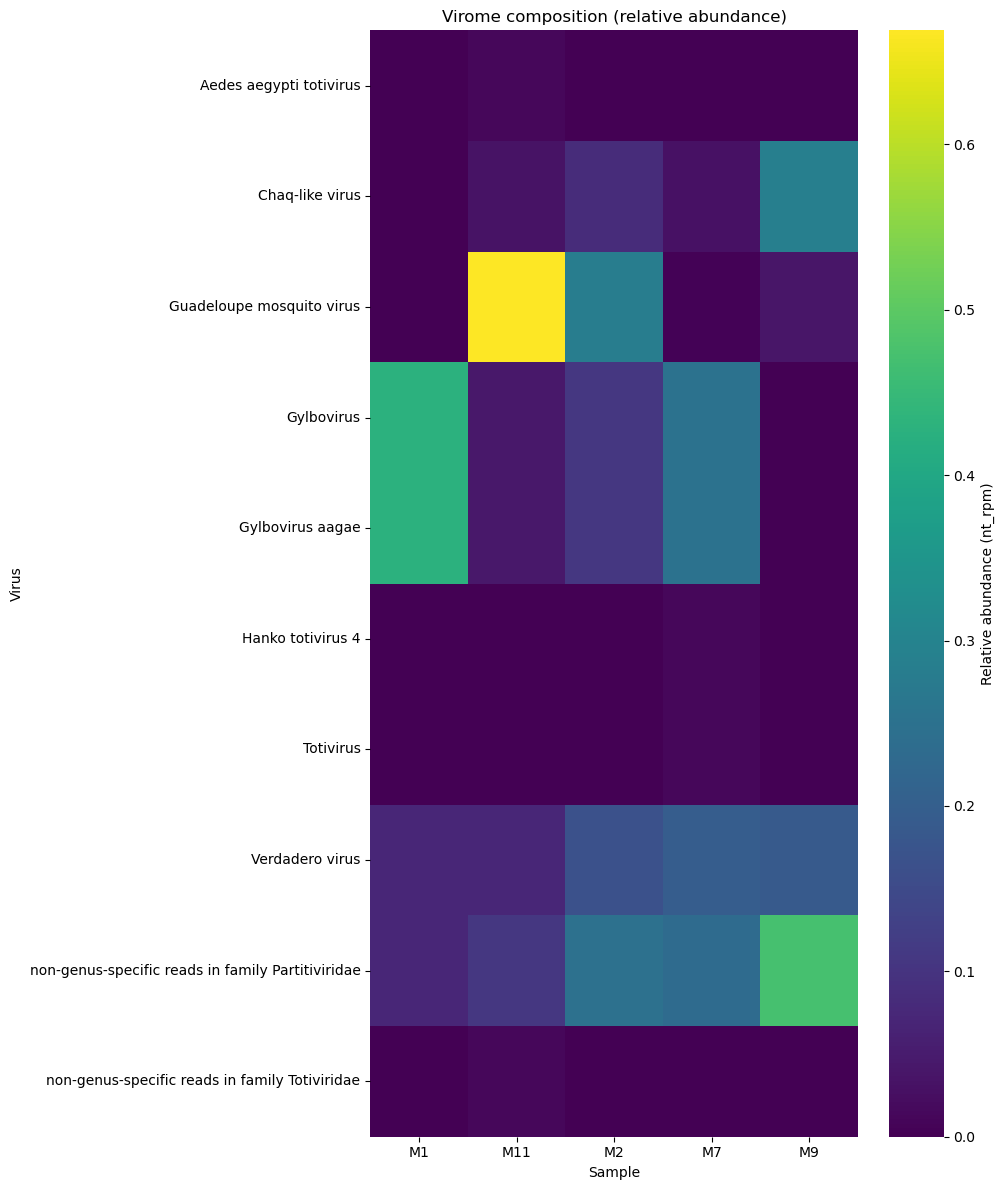

In [12]:
# Data visualization.

pivot = df_final.pivot_table(
    index="name",
    columns="sample_name", 
    values="nt_rpm",
    aggfunc="sum",
    fill_value=0
)
pivot_rel = pivot.div(pivot.sum(axis=0), axis=1)

# Low informative taxa filtering. We filter out taxa that have a relative abundance of less than 1% in all samples.
pivot_filt = pivot_rel[pivot_rel.max(axis=1) > 0.01]  # >1%

plt.figure(figsize=(10, 12))

sns.heatmap(
    pivot_filt,
    cmap="viridis",
    cbar_kws={"label": "Relative abundance (nt_rpm)"}
)

plt.title("Virome composition (relative abundance)")
plt.xlabel("Sample")
plt.ylabel("Virus")
plt.tight_layout()
plt.show()

### Total read depth by sample.

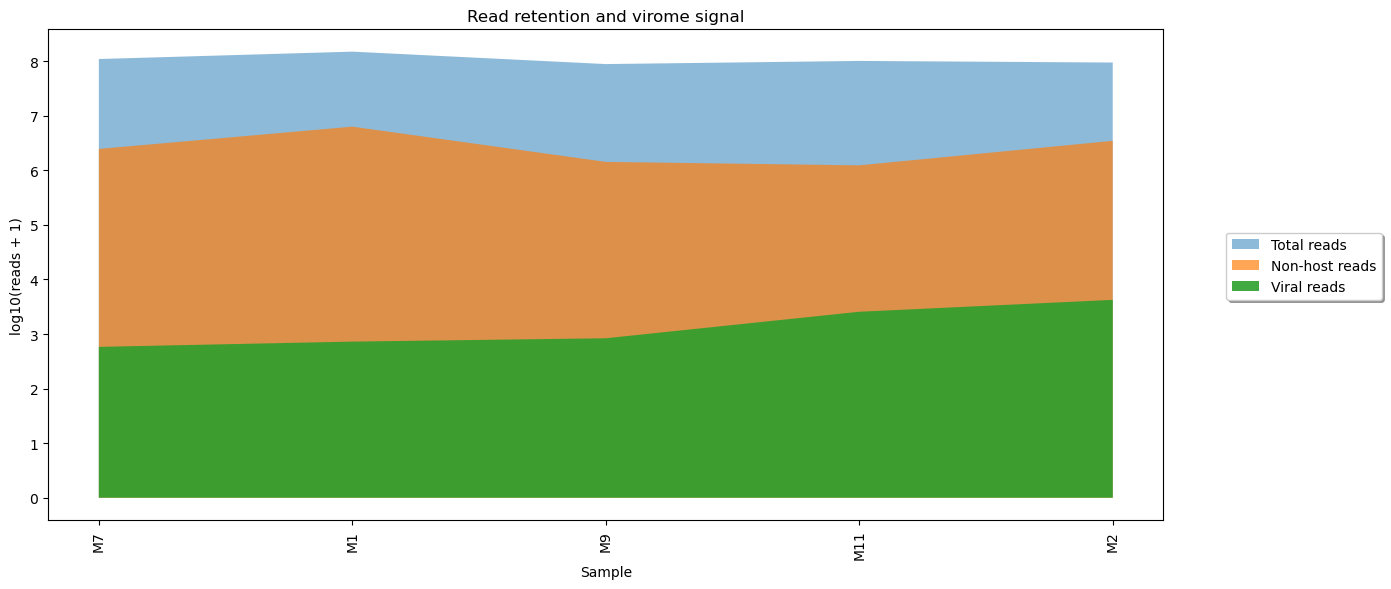

In [13]:
# Read retention and virome signal plot.

# Read definitions:
# Total reads: total number of reads in the sample before any filtering.
# Non-host reads: number of reads that remain after filtering out host reads (mosquito reads in this case).
# Viral reads: number of reads that are classified as viral by CZID.


total_reads = df_metadata.set_index("sample_name")["total_reads"] 

viral_reads = df_final.groupby("sample_name")["nt_rpm"].sum() 

non_host_reads = df_metadata.set_index("sample_name")[ "reads_after_hisat2_host_filtered" ]

df_plot = df_metadata.set_index("sample_name").copy()

# Columnn creation for plotting:
df_plot["viral_reads"] = viral_reads
df_plot["viral_reads"] = df_plot["viral_reads"].fillna(0)
df_plot["non_host_reads"] = df_plot["reads_after_hisat2_host_filtered"]

df_plot["total_log"] = np.log10(df_plot["total_reads"] + 1)
df_plot["non_host_log"] = np.log10(df_plot["non_host_reads"] + 1)
df_plot["viral_log"] = np.log10(df_plot["viral_reads"] + 1)

# Order by total reads.
df_plot = df_plot.sort_values("viral_reads", ascending=True)

# Plotting
plt.figure(figsize=(14, 6))

x = range(len(df_plot))

plt.fill_between(x, df_plot["total_log"], label="Total reads", alpha=0.5)
plt.fill_between(x, df_plot["non_host_log"], label="Non-host reads", alpha=0.7)
plt.fill_between(x, df_plot["viral_log"], label="Viral reads", alpha=0.9)

plt.xticks(x, df_plot.index, rotation=90)
plt.ylabel("log10(reads + 1)")
plt.xlabel("Sample")
plt.title("Read retention and virome signal")

plt.legend(    
    bbox_to_anchor=(1.05, 0.6),
    loc="upper left",
    frameon=True,
    fancybox=True,
    shadow=True,
    fontsize=10
    )
plt.tight_layout()
plt.show()

 

### Viral family read relative abundance by sample.

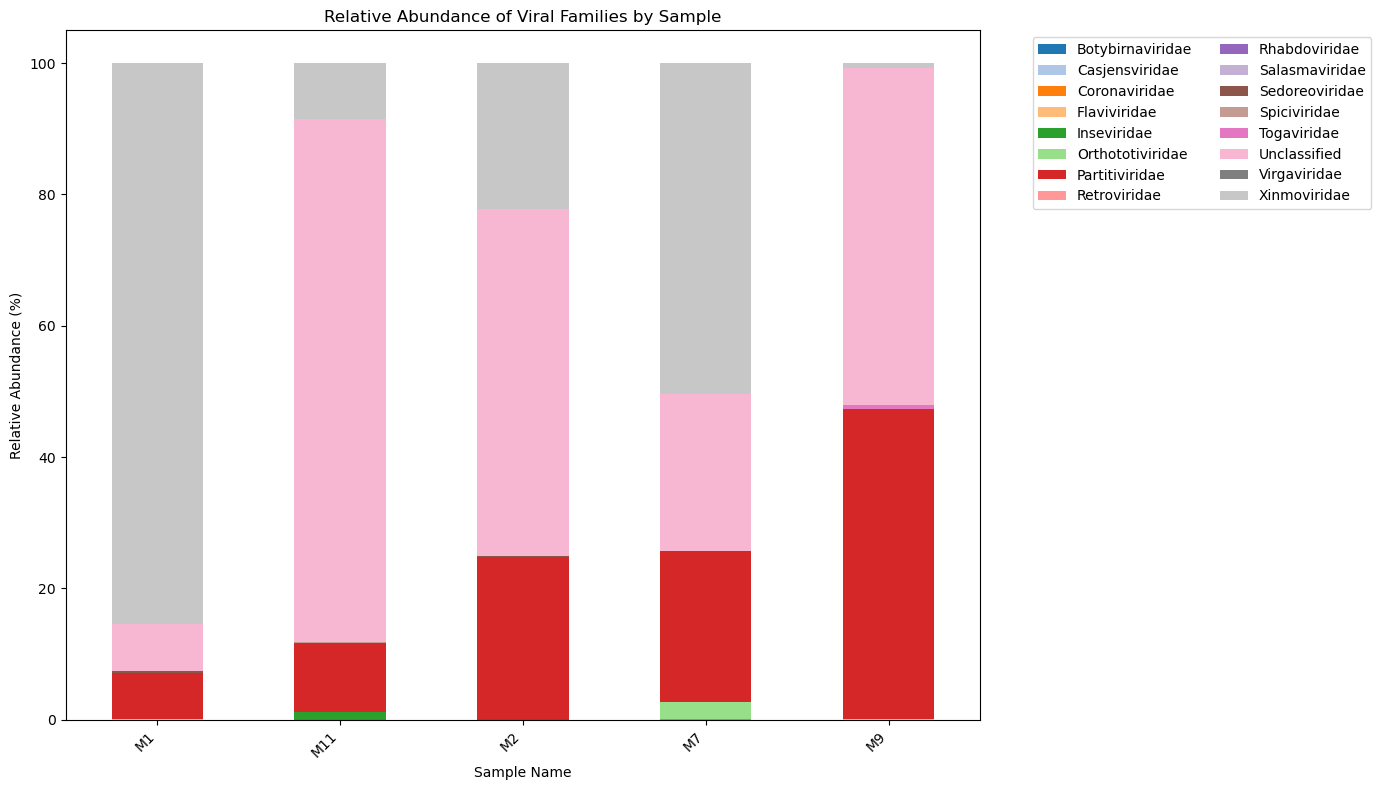

In [14]:
# Group and prepare data (same as above)
df_family_sum = df_final.groupby(['family', 'sample_name'])['nt_rpm'].sum().reset_index()
df_family_sum['relative_abundance'] = df_family_sum.groupby('sample_name')['nt_rpm'].transform(lambda x: x / x.sum() * 100)
df_family_sum = df_family_sum[df_family_sum['relative_abundance'] > 0.01]
pivot_df = df_family_sum.pivot(index='sample_name', columns='family', values='relative_abundance').fillna(0)

# Generate unique colors
unique_families = pivot_df.columns.tolist()
num_families = len(unique_families)

# Create a color palette with enough distinct colors
if num_families <= 10:
    palette = sns.color_palette("tab10", num_families)
elif num_families <= 20:
    palette = sns.color_palette("tab20", num_families)
elif num_families <= 30:
    palette = sns.color_palette("Set3", num_families)
else:
    # Create a custom palette with many distinct colors
    palette = sns.color_palette("hls", num_families)

color_dict = dict(zip(unique_families, palette))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
pivot_df.plot(kind='bar', stacked=True, color=[color_dict[col] for col in pivot_df.columns], ax=ax)

plt.title('Relative Abundance of Viral Families by Sample')
plt.xlabel('Sample Name')
plt.ylabel('Relative Abundance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()